In [ ]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit

QiskitRuntimeService.save_account(
    token="tpp6b_rAgHg41wp7FR8U-PBO6eIem-3fgqdxmHYGsRQP",
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/e2139ca576ca41d68065c46126c666a9:a0a10b16-2180-465d-9b26-986f54b3a686::",
    overwrite=True
)


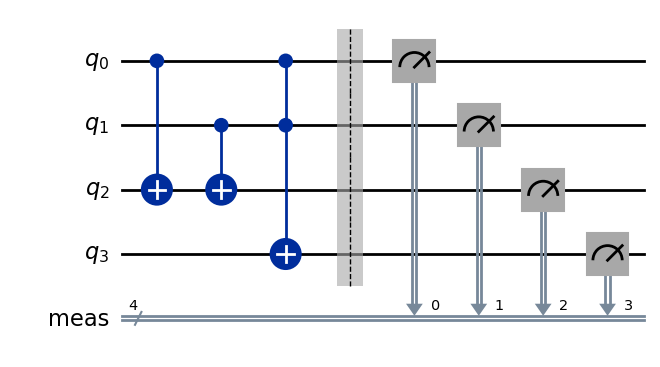

In [ ]:
# Bell 회로
# 최대 얽힘 상태

# 양자 반가산기

# 큐비트: a,b,sum,carry
qc = QuantumCircuit(4)

# A와 B에 넣을 값을 선택합니다.
a = 0
b = 0

# 선택한 값에 따라 A, B 큐비트를 준비합니다.
if a:
    qc.x(0)
if b:
    qc.x(1)

# XOR(합)를 큐비트 2에 계산
qc.cx(0, 2)
qc.cx(1, 2)

# AND(자리올림)를 큐비트 3에 계산
qc.ccx(0,1,3) # a AND b

# 측정
qc.measure_all()

qc.draw("mpl")

In [ ]:
service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
print(backend.name)

ibm_marrakesh


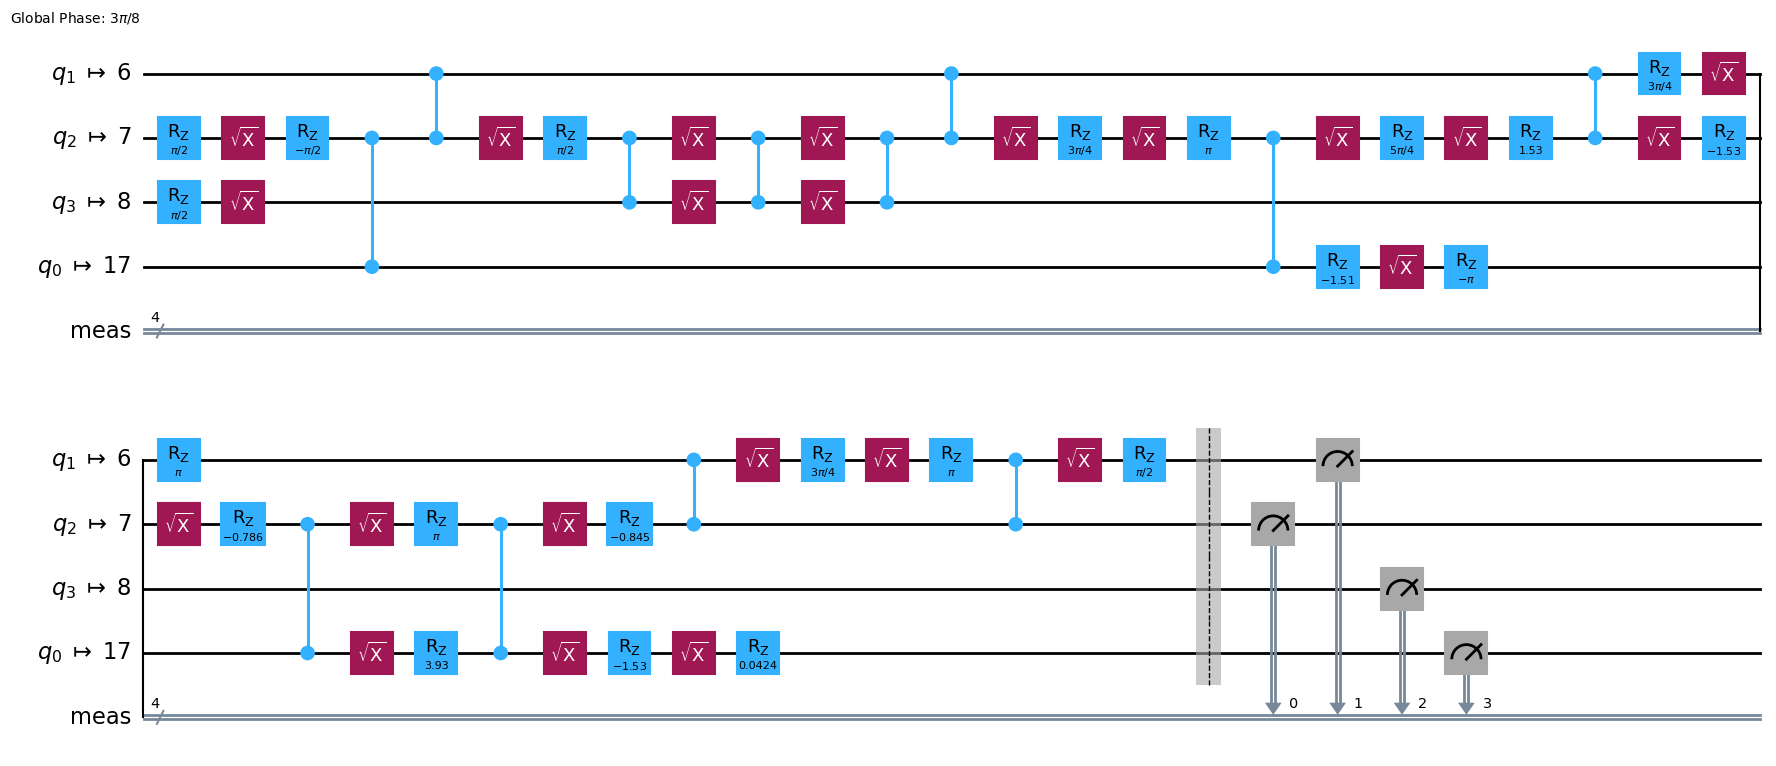

In [ ]:
# 선택한 양자 컴퓨터에서 실행 되도록 회로를 트랜스 파일하고 최적화합니다.
# 2단계: 트렌스 파일

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

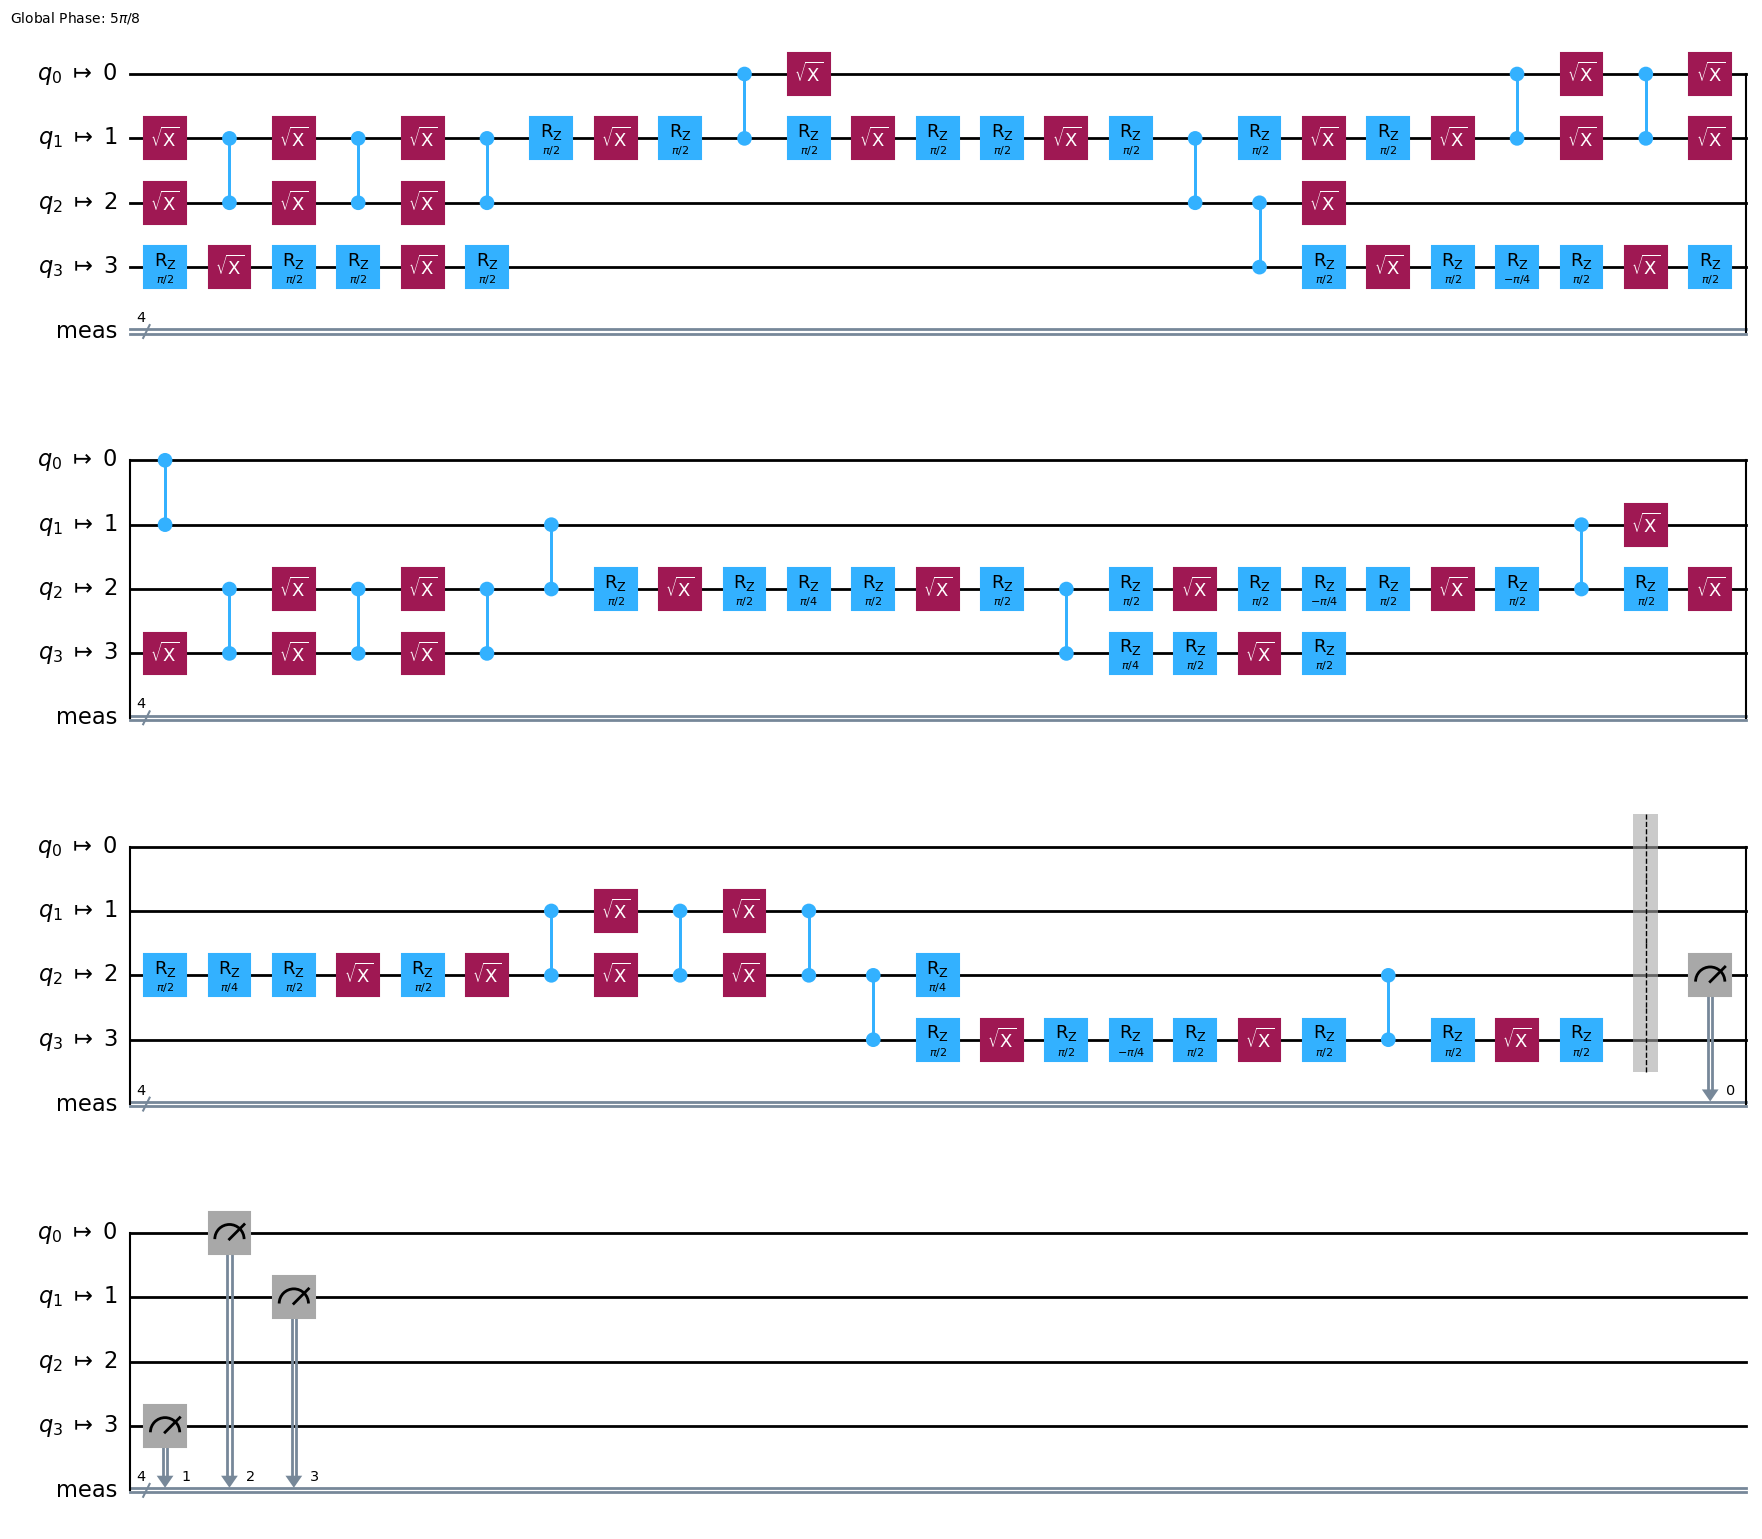

In [7]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=0)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

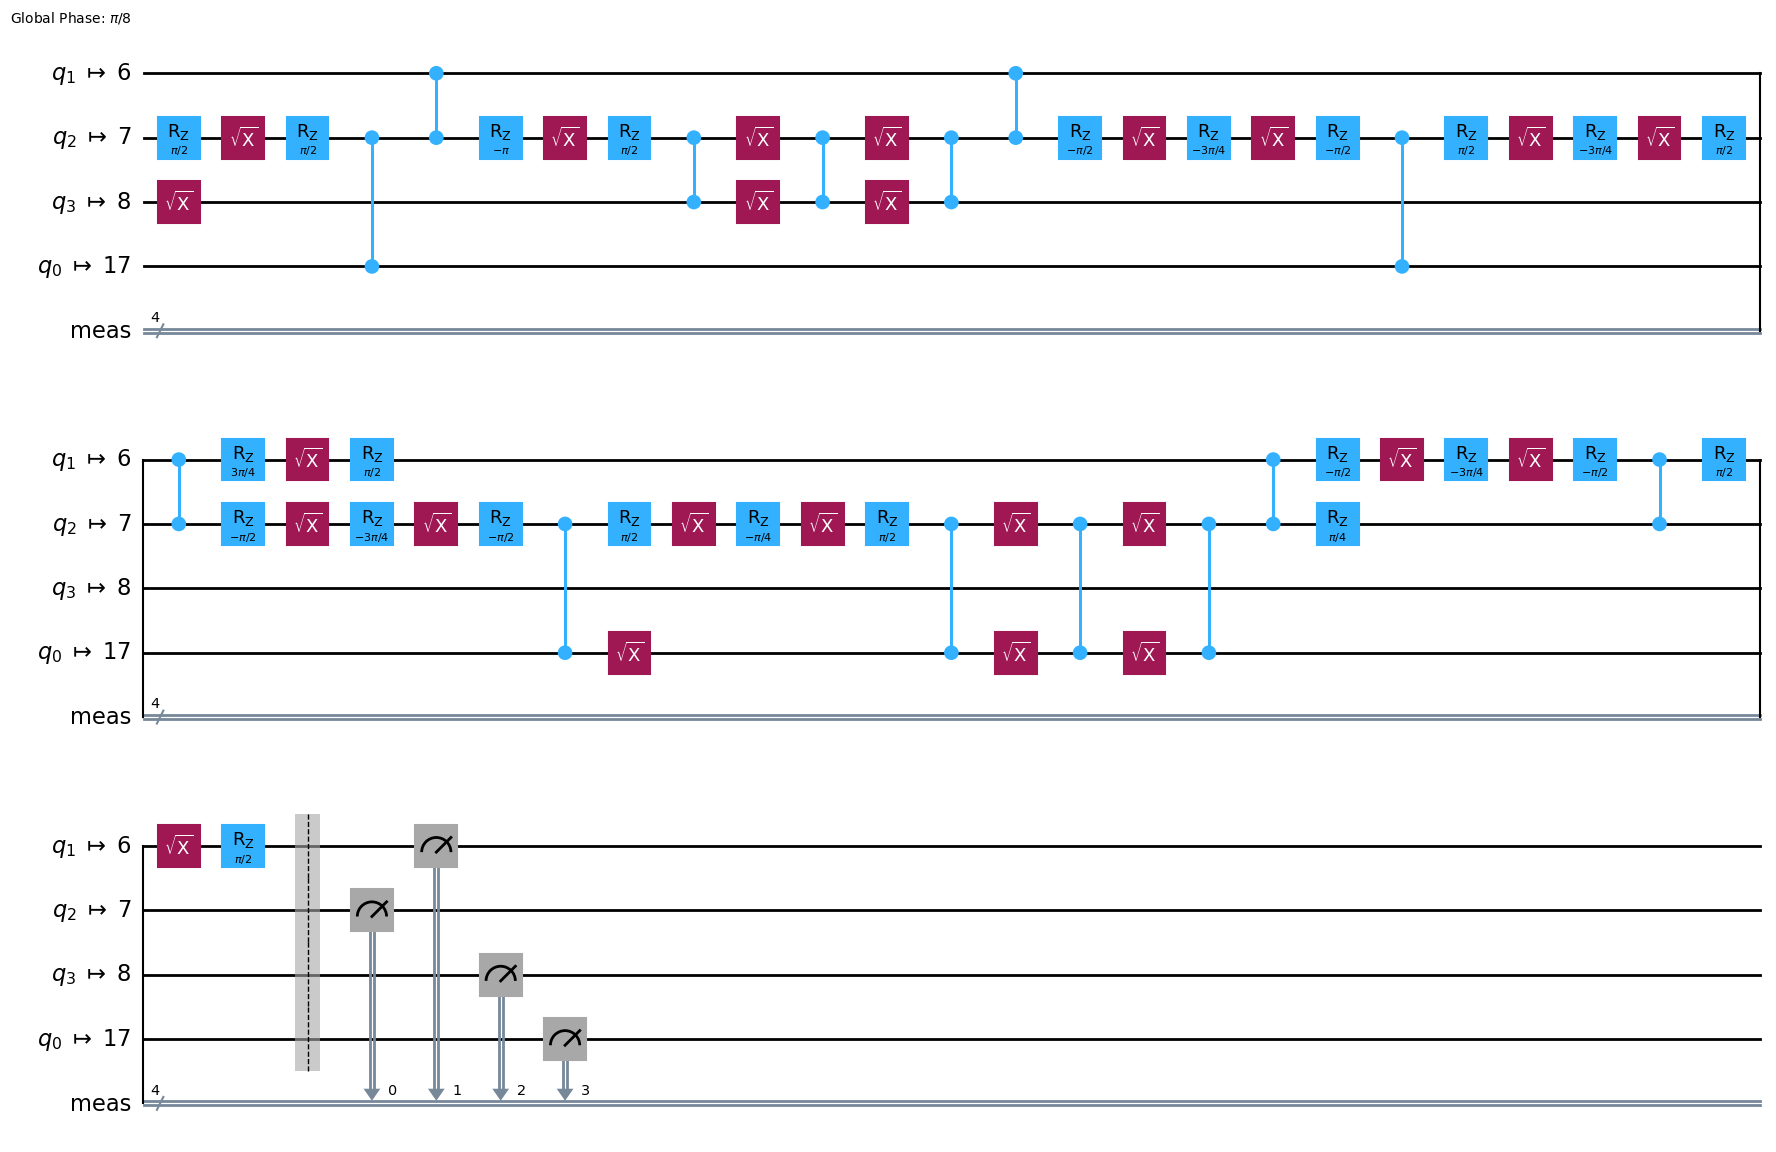

In [8]:
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=1)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

In [ ]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(mode=backend)

In [12]:
from qiskit.primitives import BackendSamplerV2

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [11]:
job = sampler.run([qc_isa], shots=100)

res = job.result()
counts = res[0].data.meas.get_counts()

c:\souce\quantumplatform\.venv\Lib\site-packages\qiskit_ibm_runtime\qiskit_runtime_service.py:1013: UserWarning: The backend ibm_marrakesh currently has a status of maintenance.
  warnings.warn(


count =  {'1000': 1, '0000': 93, '0001': 1, '0100': 3, '0010': 1, '1100': 1}


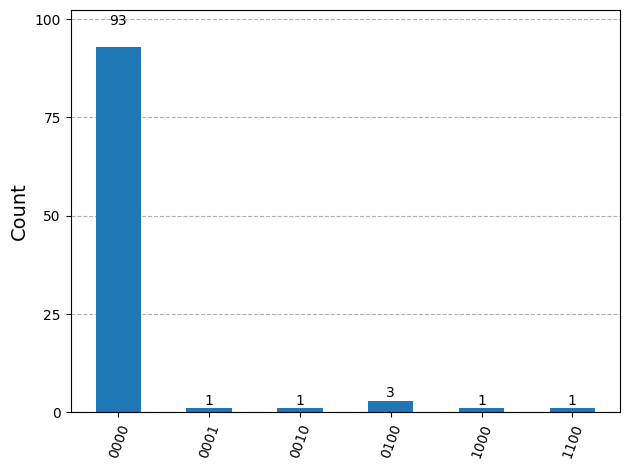

In [13]:
from qiskit.visualization import plot_histogram

print("count = ", counts)
plot_histogram(counts)